In [ ]:
import pandas as pd
from scipy import stats
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score, silhouette_samples

# Clustergram import commented out since not using
# from clustergram import Clustergram

from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.patches import FancyArrow

In [ ]:
distances_file = r"C:\Users\sgabalog\Documents\P1\lsoa_synthetic_population.csv"

# Read the data file
og_data = pd.read_csv(distances_file)
print("Data loaded successfully!")
print(f"Shape: {og_data.shape}")
print(f"Columns: {list(og_data.columns[:10])}...")  # Show first 10 columns


Data loaded successfully!
Shape: (34628, 57)
Columns: ['LSOA21CD', 'Aged_16-24', 'Aged_25-34', 'Aged_35-49', 'Age_50-64', 'Aged_65+', 'Female', 'Never_married/partnership', 'Divorced_or_Widowed', '1 person in household']...


In [10]:
range_scaled_df = og_data

In [ ]:
# CLUSTERGRAM SECTION - IGNORED AS REQUESTED
# clustergram = range_scaled_df.select_dtypes(include='number')
# cgram = Clustergram(range(1, 8), n_init=100, verbose=False)
# cgram.fit(clustergram)

In [8]:
# CLUSTERGRAM PLOTTING - IGNORED AS REQUESTED
# import matplotlib.pyplot as plt
# import seaborn as sns
# sns.set(style='whitegrid')  # Set the Seaborn style
# ax = cgram.plot(figsize=(16, 8))  # Plot without specifying color
# for line in ax.get_lines():
#     line.set_color('orange')
# ax.yaxis.grid(False)  # Remove gridlines on the y-axis
# sns.despine(offset=10)  # Remove the spines with an offset
# ax.set_title('K-Means (scikit-learn)')  # Set the title
# plt.show()

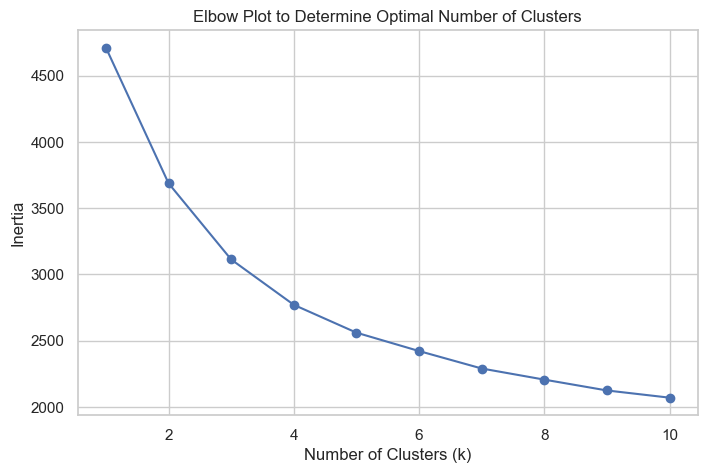

In [ ]:
# Drop the first column (LSOA21CD) for clustering
cluster_df = range_scaled_df.iloc[:, 4:]

# Determine the range of cluster numbers to try
cluster_range = range(1, 11)
inertia = []

# Compute inertia for each number of clusters
for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(cluster_df)
    inertia.append(kmeans.inertia_)

# Create the elbow plot
plt.figure(figsize=(8, 5))
plt.plot(cluster_range, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Plot to Determine Optimal Number of Clusters')
plt.grid(True)
plt.show()

In [11]:

# Import silhouette scoring
from sklearn.metrics import silhouette_score, silhouette_samples

# Drop non-numeric columns for clustering
X = range_scaled_df.select_dtypes(include='number')

# Define the optimal number of clusters (CHANGED TO 4 AS REQUESTED)
optimal_k = 4

# Initialize and fit the KMeans model
kmeans = KMeans(n_clusters=optimal_k, random_state=40)
cluster_labels = kmeans.fit_predict(X)
range_scaled_df['Cluster'] = cluster_labels

# Calculate silhouette scores for 4 main clusters
avg_silhouette_score = silhouette_score(X, cluster_labels)
sample_silhouette_values = silhouette_samples(X, cluster_labels)

print("=== MAIN CLUSTER ANALYSIS (4 CLUSTERS) ===")
print(f"Average Silhouette Score for 4 clusters: {avg_silhouette_score:.4f}")
print(f"Cluster distribution:")
print(range_scaled_df['Cluster'].value_counts().sort_index())

# Display the first few rows with the cluster assignments
print(f"\nFirst few rows with cluster assignments:")
print(range_scaled_df[['LSOA21CD', 'Cluster']].head())

df = range_scaled_df


=== MAIN CLUSTER ANALYSIS (4 CLUSTERS) ===
Average Silhouette Score for 4 clusters: 0.1577
Cluster distribution:
0     8099
1    10947
2     4728
3    10854
Name: Cluster, dtype: int64

First few rows with cluster assignments:
    LSOA21CD  Cluster
0  E01011954        0
1  E01011969        3
2  E01011970        3
3  E01011971        3
4  E01033465        3


In [12]:
from sklearn.cluster import KMeans

def create_subclusters(df, main_cluster, subcluster_count):
    # Step 1: Check if the main cluster exists
    if main_cluster not in df['Cluster'].unique():
        raise ValueError(f"Main cluster {main_cluster} does not exist in the dataset.")

    # Step 2: Filter the data for rows where Cluster equals the specified main cluster
    cluster_data = df[df['Cluster'] == main_cluster]

    # Step 3: Drop non-numeric columns for subclustering
    X_subcluster = cluster_data.select_dtypes(include='number').drop(columns=['Cluster'])

    # Step 4: Initialize and fit the KMeans model for subclustering
    sub_kmeans = KMeans(n_clusters=subcluster_count, random_state=40)
    cluster_data['Subcluster'] = sub_kmeans.fit_predict(X_subcluster)

    # Step 5: Create subcluster labels (e.g., 2.1, 2.2, 2.3)
    cluster_data['Subcluster'] = cluster_data['Subcluster'].apply(lambda x: f"{main_cluster}.{x + 1}")

    # Step 6: Update the Subcluster column in the original dataframe
    df = df.copy()  # Avoid modifying the original dataframe directly
    df.loc[df['Cluster'] == main_cluster, 'Subcluster'] = cluster_data['Subcluster']

    # Step 7: Fill NaN values in the Subcluster column for rows outside the main cluster
    df['Subcluster'] = df['Subcluster'].fillna('No Subcluster')

    return df

# CREATE SUBCLUSTERS AS REQUESTED:
# - Clusters 0, 1, 2: 2 subclusters each  
# - Cluster 3: 3 subclusters (since we now have clusters 0-3, cluster 3 is the "4th" cluster)

print("\n=== CREATING SUBCLUSTERS ===")

# Initialize the Subcluster column
range_scaled_df['Subcluster'] = 'No Subcluster'

# Create 2 subclusters for clusters 0, 1, 2
for cluster_num in [0, 1, 2]:
    if cluster_num in range_scaled_df['Cluster'].unique():
        print(f"Creating 2 subclusters for Cluster {cluster_num}...")
        range_scaled_df = create_subclusters(range_scaled_df, cluster_num, 2)

# Create 3 subclusters for cluster 3 (the "4th" cluster)
if 3 in range_scaled_df['Cluster'].unique():
    print(f"Creating 3 subclusters for Cluster 3...")
    range_scaled_df = create_subclusters(range_scaled_df, 3, 3)

# Display the subcluster distribution
print(f"\nSubcluster distribution:")
print(range_scaled_df['Subcluster'].value_counts().sort_index())

# Display the first few rows with the cluster and subcluster assignments
print(f"\nFirst few rows with cluster and subcluster assignments:")
print(range_scaled_df[['LSOA21CD', 'Cluster', 'Subcluster']].head(10))



=== CREATING SUBCLUSTERS ===
Creating 2 subclusters for Cluster 0...


C:\Users\sgabalog\AppData\Local\Temp\ipykernel_15388\4263707330.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_data['Subcluster'] = sub_kmeans.fit_predict(X_subcluster)
C:\Users\sgabalog\AppData\Local\Temp\ipykernel_15388\4263707330.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_data['Subcluster'] = cluster_data['Subcluster'].apply(lambda x: f"{main_cluster}.{x + 1}")


Creating 2 subclusters for Cluster 1...


C:\Users\sgabalog\AppData\Local\Temp\ipykernel_15388\4263707330.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_data['Subcluster'] = sub_kmeans.fit_predict(X_subcluster)
C:\Users\sgabalog\AppData\Local\Temp\ipykernel_15388\4263707330.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_data['Subcluster'] = cluster_data['Subcluster'].apply(lambda x: f"{main_cluster}.{x + 1}")


Creating 2 subclusters for Cluster 2...


C:\Users\sgabalog\AppData\Local\Temp\ipykernel_15388\4263707330.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_data['Subcluster'] = sub_kmeans.fit_predict(X_subcluster)
C:\Users\sgabalog\AppData\Local\Temp\ipykernel_15388\4263707330.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_data['Subcluster'] = cluster_data['Subcluster'].apply(lambda x: f"{main_cluster}.{x + 1}")


Creating 3 subclusters for Cluster 3...

Subcluster distribution:
0.1    5470
0.2    2629
1.1    5407
1.2    5540
2.1    3607
2.2    1121
3.1    2972
3.2    4176
3.3    3706
Name: Subcluster, dtype: int64

First few rows with cluster and subcluster assignments:
    LSOA21CD  Cluster Subcluster
0  E01011954        0        0.2
1  E01011969        3        3.3
2  E01011970        3        3.3
3  E01011971        3        3.2
4  E01033465        3        3.2
5  E01033467        1        1.2
6  E01011952        0        0.1
7  E01011953        0        0.1
8  E01011991        1        1.1
9  E01011992        0        0.2


C:\Users\sgabalog\AppData\Local\Temp\ipykernel_15388\4263707330.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_data['Subcluster'] = sub_kmeans.fit_predict(X_subcluster)
C:\Users\sgabalog\AppData\Local\Temp\ipykernel_15388\4263707330.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_data['Subcluster'] = cluster_data['Subcluster'].apply(lambda x: f"{main_cluster}.{x + 1}")


In [13]:
# CALCULATE SILHOUETTE SCORES FOR ALL SUBCLUSTERS
print("\n=== SILHOUETTE SCORES FOR SUBCLUSTERS ===")

# Get unique subclusters (excluding 'No Subcluster')
subclusters = [sc for sc in range_scaled_df['Subcluster'].unique() if sc != 'No Subcluster']

# For each main cluster, calculate silhouette scores for its subclusters
for main_cluster in [0, 1, 2, 3]:
    cluster_subclusters = [sc for sc in subclusters if sc.startswith(str(main_cluster) + '.')]
    
    if cluster_subclusters:
        print(f"\nMain Cluster {main_cluster} subclusters: {cluster_subclusters}")
        
        # Get data for this main cluster only
        cluster_data = range_scaled_df[range_scaled_df['Cluster'] == main_cluster]
        X_cluster = cluster_data.select_dtypes(include='number').drop(columns=['Cluster'])
        
        # Create numeric labels for subclusters (0, 1, 2, ...)
        subcluster_mapping = {sc: i for i, sc in enumerate(cluster_subclusters)}
        numeric_subcluster_labels = cluster_data['Subcluster'].map(subcluster_mapping)
        
        # Calculate silhouette score for subclusters within this main cluster
        if len(cluster_subclusters) > 1:  # Need at least 2 clusters for silhouette
            avg_silhouette = silhouette_score(X_cluster, numeric_subcluster_labels)
            print(f"Average Silhouette Score for Cluster {main_cluster} subclusters: {avg_silhouette:.4f}")
            
            # Individual subcluster sizes
            for sc in cluster_subclusters:
                size = len(cluster_data[cluster_data['Subcluster'] == sc])
                print(f"  - {sc}: {size} data points")
        else:
            print(f"Only one subcluster found for Cluster {main_cluster}")

# Save results
#range_scaled_df.to_csv(r'C:\Users\sgabalog\Documents\P1\3rd_draft\sublcusters_done.csv', index=False)
#print(f"\nResults saved to: sublcusters_done.csv")


=== SILHOUETTE SCORES FOR SUBCLUSTERS ===

Main Cluster 0 subclusters: ['0.2', '0.1']
Average Silhouette Score for Cluster 0 subclusters: 0.1392
  - 0.2: 2629 data points
  - 0.1: 5470 data points

Main Cluster 1 subclusters: ['1.2', '1.1']
Average Silhouette Score for Cluster 1 subclusters: 0.1280
  - 1.2: 5540 data points
  - 1.1: 5407 data points

Main Cluster 2 subclusters: ['2.2', '2.1']
Average Silhouette Score for Cluster 2 subclusters: 0.2122
  - 2.2: 1121 data points
  - 2.1: 3607 data points

Main Cluster 3 subclusters: ['3.3', '3.2', '3.1']
Average Silhouette Score for Cluster 3 subclusters: 0.1350
  - 3.3: 3706 data points
  - 3.2: 4176 data points
  - 3.1: 2972 data points


In [ ]:
# COMPREHENSIVE SILHOUETTE ANALYSIS SUMMARY
print("="*60)
print("COMPREHENSIVE SILHOUETTE ANALYSIS SUMMARY")
print("="*60)

print(f"\n📊 MAIN CLUSTERS (K=4):")
print(f"Overall Silhouette Score: {avg_silhouette_score:.4f}")
print(f"Cluster sizes:")
for cluster in sorted(range_scaled_df['Cluster'].unique()):
    size = len(range_scaled_df[range_scaled_df['Cluster'] == cluster])
    print(f"  Cluster {cluster}: {size} data points")

print(f"\n🎯 SUBCLUSTERS CREATED:")
print(f"• Clusters 0, 1, 2: 2 subclusters each")
print(f"• Cluster 3: 3 subclusters")

print(f"\n📈 SUBCLUSTER SILHOUETTE SCORES:")
# Recalculate and display all subcluster silhouette scores in summary
for main_cluster in [0, 1, 2, 3]:
    cluster_subclusters = [sc for sc in range_scaled_df['Subcluster'].unique() 
                          if sc != 'No Subcluster' and sc.startswith(str(main_cluster) + '.')]
    
    if cluster_subclusters and len(cluster_subclusters) > 1:
        cluster_data = range_scaled_df[range_scaled_df['Cluster'] == main_cluster]
        X_cluster = cluster_data.select_dtypes(include='number').drop(columns=['Cluster'])
        subcluster_mapping = {sc: i for i, sc in enumerate(cluster_subclusters)}
        numeric_subcluster_labels = cluster_data['Subcluster'].map(subcluster_mapping)
        avg_silhouette = silhouette_score(X_cluster, numeric_subcluster_labels)
        print(f"  Cluster {main_cluster} subclusters: {avg_silhouette:.4f}")


,LSOAXXCD,LSOA11CD,LSOA21CD,CHG21,Aged_16-24,Aged_25-34,Aged_35-49,Age_50-64,Female,Never_married/partnership,...,Online Often,Online_Sometimes/Rarely,IUC Online Retail Engagement,high_PT_supermarket_access,high_PT_sub_bua_access,high_car_access_supermarket,Urban Setting,No cars or vans in household,Cluster,Subcluster
0,X0000001E,E01031349,E01031349,U,0.726488,0.401546,0.486190,0.496551,0.203259,0.485259,...,0.586312,0.527270,0.5,0,0,1,1,0.578388,4,4.2
1,X0000002E,E01031350,E01031350,U,0.782622,0.562050,0.536255,0.429161,0.232093,0.619479,...,0.501488,0.405458,0.0,0,0,1,1,0.654260,2,2.2
2,X0000003E,E01031351,E01031351,U,0.757425,0.373775,0.518563,0.485032,0.188978,0.488649,...,0.572554,0.584648,0.5,1,0,1,1,0.542416,1,1.1
3,X0000004E,E01031352,E01031352,U,0.744493,0.468681,0.439256,0.481218,0.251423,0.517930,...,0.679624,0.518231,0.0,1,0,1,1,0.586908,1,1.1
4,X0000005E,E01031370,E01031370,U,0.831468,0.416291,0.530355,0.397036,0.209640,0.602220,...,0.494857,0.514327,0.0,1,0,1,1,0.581263,2,2.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35791,X0034629E,E01013336,E01013336,U,0.722610,0.468681,0.503838,0.496551,0.164613,0.511607,...,0.524565,0.467063,0.5,1,0,1,1,0.678157,1,1.1
35792,X0034630E,E01013337,E01013337,U,0.714549,0.539718,0.462700,0.531793,0.188978,0.531798,...,0.636413,0.547696,0.5,1,0,1,1,0.613234,1,1.1
35793,X0034631E,E01013338,E01013338,U,0.782622,0.542033,0.571709,0.342559,0.194996,0.559556,...,0.559047,0.558052,0.5,0,0,1,1,0.613234,4,4.1
35794,X0034632E,E01013339,E01013339,U,0.760477,0.433717,0.527406,0.466087,0.194996,0.462502,...,0.559056,0.723322,0.5,0,0,1,1,0.566512,4,4.2


In [14]:
# ================================================================
# COMPREHENSIVE CLUSTERING METHOD COMPARISON
# ================================================================

print("🔬 EXPLORING ALTERNATIVE CLUSTERING METHODS")
print("="*60)

from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Prepare the data (ensure it's properly scaled)
X_analysis = range_scaled_df.select_dtypes(include='number').drop(columns=['Cluster'], errors='ignore')
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_analysis)

# Store results
results = []

print(f"Dataset info: {X_scaled.shape[0]} samples, {X_scaled.shape[1]} features")
print("Testing multiple clustering algorithms...\n")


🔬 EXPLORING ALTERNATIVE CLUSTERING METHODS
Dataset info: 34628 samples, 56 features
Testing multiple clustering algorithms...



In [15]:
# 1. K-MEANS WITH DIFFERENT K VALUES
print("1️⃣ K-MEANS CLUSTERING (Different K values)")
print("-" * 50)

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    # Calculate metrics
    silhouette_avg = silhouette_score(X_scaled, labels)
    calinski_harabasz = calinski_harabasz_score(X_scaled, labels)
    davies_bouldin = davies_bouldin_score(X_scaled, labels)
    
    results.append({
        'Method': f'K-Means (k={k})',
        'Silhouette': silhouette_avg,
        'Calinski-Harabasz': calinski_harabasz,
        'Davies-Bouldin': davies_bouldin,
        'n_clusters': k
    })
    
    print(f"K={k}: Silhouette={silhouette_avg:.4f}, CH={calinski_harabasz:.1f}, DB={davies_bouldin:.4f}")

print()


1️⃣ K-MEANS CLUSTERING (Different K values)
--------------------------------------------------
K=2: Silhouette=0.2440, CH=13352.5, DB=1.5381
K=3: Silhouette=0.1970, CH=9267.6, DB=1.9517
K=4: Silhouette=0.1486, CH=7731.1, DB=1.9224
K=5: Silhouette=0.1302, CH=6767.9, DB=1.8965
K=6: Silhouette=0.1326, CH=6102.6, DB=1.8754
K=7: Silhouette=0.1199, CH=5581.1, DB=1.9138



In [16]:
# 2. HIERARCHICAL CLUSTERING
print("2️⃣ HIERARCHICAL CLUSTERING (Agglomerative)")
print("-" * 50)

linkage_methods = ['ward', 'complete', 'average', 'single']

for linkage in linkage_methods:
    for k in [3, 4, 5]:
        try:
            if linkage == 'ward':
                # Ward only works with euclidean distance
                agg = AgglomerativeClustering(n_clusters=k, linkage=linkage)
            else:
                agg = AgglomerativeClustering(n_clusters=k, linkage=linkage)
            
            labels = agg.fit_predict(X_scaled)
            
            # Calculate metrics
            silhouette_avg = silhouette_score(X_scaled, labels)
            calinski_harabasz = calinski_harabasz_score(X_scaled, labels)
            davies_bouldin = davies_bouldin_score(X_scaled, labels)
            
            results.append({
                'Method': f'Hierarchical-{linkage} (k={k})',
                'Silhouette': silhouette_avg,
                'Calinski-Harabasz': calinski_harabasz,
                'Davies-Bouldin': davies_bouldin,
                'n_clusters': k
            })
            
            print(f"{linkage.capitalize()}-k={k}: Silhouette={silhouette_avg:.4f}, CH={calinski_harabasz:.1f}, DB={davies_bouldin:.4f}")
        except Exception as e:
            print(f"{linkage.capitalize()}-k={k}: Error - {str(e)[:50]}...")

print()


2️⃣ HIERARCHICAL CLUSTERING (Agglomerative)
--------------------------------------------------
Ward-k=3: Silhouette=0.1793, CH=8188.5, DB=2.0773
Ward-k=4: Silhouette=0.1274, CH=6344.2, DB=2.2203
Ward-k=5: Silhouette=0.0965, CH=5369.2, DB=2.2607
Complete-k=3: Silhouette=0.0540, CH=3606.5, DB=2.7977
Complete-k=4: Silhouette=0.0540, CH=2409.4, DB=2.1660
Complete-k=5: Silhouette=0.0459, CH=2731.2, DB=1.7840
Average-k=3: Silhouette=0.5258, CH=22.9, DB=0.4703
Average-k=4: Silhouette=0.4224, CH=25.4, DB=0.6495
Average-k=5: Silhouette=0.3443, CH=22.9, DB=0.7981
Single-k=3: Silhouette=0.5715, CH=10.1, DB=0.3010
Single-k=4: Silhouette=0.4117, CH=8.3, DB=0.3746
Single-k=5: Silhouette=0.3853, CH=7.4, DB=0.3872



In [17]:
# 3. GAUSSIAN MIXTURE MODELS
print("3️⃣ GAUSSIAN MIXTURE MODELS")
print("-" * 50)

for k in range(2, 8):
    try:
        gmm = GaussianMixture(n_components=k, random_state=42, max_iter=100)
        labels = gmm.fit_predict(X_scaled)
        
        # Calculate metrics
        silhouette_avg = silhouette_score(X_scaled, labels)
        calinski_harabasz = calinski_harabasz_score(X_scaled, labels)
        davies_bouldin = davies_bouldin_score(X_scaled, labels)
        
        results.append({
            'Method': f'GMM (k={k})',
            'Silhouette': silhouette_avg,
            'Calinski-Harabasz': calinski_harabasz,
            'Davies-Bouldin': davies_bouldin,
            'n_clusters': k
        })
        
        print(f"GMM k={k}: Silhouette={silhouette_avg:.4f}, CH={calinski_harabasz:.1f}, DB={davies_bouldin:.4f}")
    except Exception as e:
        print(f"GMM k={k}: Error - {str(e)[:50]}...")

print()


3️⃣ GAUSSIAN MIXTURE MODELS
--------------------------------------------------
GMM k=2: Silhouette=0.2239, CH=10926.5, DB=1.7148
GMM k=3: Silhouette=0.1542, CH=7120.2, DB=2.6404
GMM k=4: Silhouette=0.0995, CH=6384.4, DB=2.5712
GMM k=5: Silhouette=0.0786, CH=5080.2, DB=2.4753
GMM k=6: Silhouette=0.0651, CH=4642.8, DB=2.6673
GMM k=7: Silhouette=0.0682, CH=4244.9, DB=2.6748



In [18]:
# 4. DBSCAN (Density-Based Clustering)
print("4️⃣ DBSCAN CLUSTERING")
print("-" * 50)

# Test different eps values for DBSCAN
eps_values = [0.3, 0.5, 0.7, 1.0, 1.5]
min_samples_values = [5, 10, 15]

for eps in eps_values:
    for min_samples in min_samples_values:
        try:
            dbscan = DBSCAN(eps=eps, min_samples=min_samples)
            labels = dbscan.fit_predict(X_scaled)
            
            # Count clusters (excluding noise points labeled as -1)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            n_noise = list(labels).count(-1)
            
            if n_clusters > 1:  # Need at least 2 clusters for silhouette
                silhouette_avg = silhouette_score(X_scaled, labels)
                calinski_harabasz = calinski_harabasz_score(X_scaled, labels)
                davies_bouldin = davies_bouldin_score(X_scaled, labels)
                
                results.append({
                    'Method': f'DBSCAN (eps={eps}, min_samples={min_samples})',
                    'Silhouette': silhouette_avg,
                    'Calinski-Harabasz': calinski_harabasz,
                    'Davies-Bouldin': davies_bouldin,
                    'n_clusters': n_clusters
                })
                
                print(f"DBSCAN eps={eps}, min_samples={min_samples}: {n_clusters} clusters, {n_noise} noise points")
                print(f"  Silhouette={silhouette_avg:.4f}, CH={calinski_harabasz:.1f}, DB={davies_bouldin:.4f}")
            else:
                print(f"DBSCAN eps={eps}, min_samples={min_samples}: {n_clusters} clusters (too few for metrics)")
        except Exception as e:
            print(f"DBSCAN eps={eps}, min_samples={min_samples}: Error - {str(e)[:50]}...")

print()


4️⃣ DBSCAN CLUSTERING
--------------------------------------------------
DBSCAN eps=0.3, min_samples=5: 0 clusters (too few for metrics)
DBSCAN eps=0.3, min_samples=10: 0 clusters (too few for metrics)
DBSCAN eps=0.3, min_samples=15: 0 clusters (too few for metrics)
DBSCAN eps=0.5, min_samples=5: 0 clusters (too few for metrics)
DBSCAN eps=0.5, min_samples=10: 0 clusters (too few for metrics)
DBSCAN eps=0.5, min_samples=15: 0 clusters (too few for metrics)
DBSCAN eps=0.7, min_samples=5: 0 clusters (too few for metrics)
DBSCAN eps=0.7, min_samples=10: 0 clusters (too few for metrics)
DBSCAN eps=0.7, min_samples=15: 0 clusters (too few for metrics)
DBSCAN eps=1.0, min_samples=5: 0 clusters (too few for metrics)
DBSCAN eps=1.0, min_samples=10: 0 clusters (too few for metrics)
DBSCAN eps=1.0, min_samples=15: 0 clusters (too few for metrics)
DBSCAN eps=1.5, min_samples=5: 0 clusters (too few for metrics)
DBSCAN eps=1.5, min_samples=10: 0 clusters (too few for metrics)
DBSCAN eps=1.5, min_sa

In [19]:
# 5. COMPREHENSIVE RESULTS SUMMARY & RANKING
print("📊 COMPREHENSIVE CLUSTERING RESULTS SUMMARY")
print("="*70)

# Convert results to DataFrame for easy analysis
import pandas as pd
results_df = pd.DataFrame(results)

if not results_df.empty:
    # Sort by Silhouette score (higher is better)
    results_df_sorted = results_df.sort_values('Silhouette', ascending=False)
    
    print("🏆 TOP 10 METHODS BY SILHOUETTE SCORE:")
    print("-" * 70)
    print(f"{'Rank':<4} {'Method':<35} {'Silhouette':<12} {'CH Index':<12} {'DB Index':<10}")
    print("-" * 70)
    
    for i, (_, row) in enumerate(results_df_sorted.head(10).iterrows(), 1):
        print(f"{i:<4} {row['Method']:<35} {row['Silhouette']:<12.4f} {row['Calinski-Harabasz']:<12.1f} {row['Davies-Bouldin']:<10.4f}")
    
    print("\n" + "="*70)
    
    # Best method overall
    best_method = results_df_sorted.iloc[0]
    print(f"🥇 BEST OVERALL METHOD:")
    print(f"   Method: {best_method['Method']}")
    print(f"   Silhouette Score: {best_method['Silhouette']:.4f}")
    print(f"   Calinski-Harabasz Index: {best_method['Calinski-Harabasz']:.1f}")
    print(f"   Davies-Bouldin Index: {best_method['Davies-Bouldin']:.4f}")
    print(f"   Number of Clusters: {best_method['n_clusters']}")
    
    # Additional insights
    print(f"\n📈 PERFORMANCE INSIGHTS:")
    avg_silhouette = results_df['Silhouette'].mean()
    print(f"   Average Silhouette Score across all methods: {avg_silhouette:.4f}")
    print(f"   Best Silhouette Score: {results_df['Silhouette'].max():.4f}")
    print(f"   Worst Silhouette Score: {results_df['Silhouette'].min():.4f}")
    
    # Method type analysis
    kmeans_results = results_df[results_df['Method'].str.contains('K-Means')]
    hierarchical_results = results_df[results_df['Method'].str.contains('Hierarchical')]
    gmm_results = results_df[results_df['Method'].str.contains('GMM')]
    dbscan_results = results_df[results_df['Method'].str.contains('DBSCAN')]
    
    print(f"\n🔍 METHOD TYPE COMPARISON:")
    if not kmeans_results.empty:
        print(f"   K-Means best: {kmeans_results['Silhouette'].max():.4f}")
    if not hierarchical_results.empty:
        print(f"   Hierarchical best: {hierarchical_results['Silhouette'].max():.4f}")
    if not gmm_results.empty:
        print(f"   GMM best: {gmm_results['Silhouette'].max():.4f}")
    if not dbscan_results.empty and len(dbscan_results) > 0:
        print(f"   DBSCAN best: {dbscan_results['Silhouette'].max():.4f}")
    
else:
    print("No clustering results to display.")

print("\n" + "="*70)


📊 COMPREHENSIVE CLUSTERING RESULTS SUMMARY
🏆 TOP 10 METHODS BY SILHOUETTE SCORE:
----------------------------------------------------------------------
Rank Method                              Silhouette   CH Index     DB Index  
----------------------------------------------------------------------
1    Hierarchical-single (k=3)           0.5715       10.1         0.3010    
2    Hierarchical-average (k=3)          0.5258       22.9         0.4703    
3    Hierarchical-average (k=4)          0.4224       25.4         0.6495    
4    Hierarchical-single (k=4)           0.4117       8.3          0.3746    
5    Hierarchical-single (k=5)           0.3853       7.4          0.3872    
6    Hierarchical-average (k=5)          0.3443       22.9         0.7981    
7    K-Means (k=2)                       0.2440       13352.5      1.5381    
8    GMM (k=2)                           0.2239       10926.5      1.7148    
9    K-Means (k=3)                       0.1970       9267.6       1.9517  

In [ ]:
# 6. RECOMMENDATIONS & METRIC INTERPRETATIONS
print("💡 CLUSTERING RECOMMENDATIONS & INTERPRETATIONS")
print("="*70)

print("📋 METRIC INTERPRETATIONS:")
print("• Silhouette Score:")
print("  - Range: -1 to +1 (higher is better)")
print("  - >0.7: Excellent  |  0.5-0.7: Good  |  0.3-0.5: Fair  |  <0.3: Poor")
print()
print("• Calinski-Harabasz Index (Variance Ratio):")
print("  - Range: 0 to ∞ (higher is better)")
print("  - Measures ratio of between-cluster to within-cluster dispersion")
print()
print("• Davies-Bouldin Index:")
print("  - Range: 0 to ∞ (lower is better)")
print("  - Measures average similarity ratio of clusters")

print("\n" + "-"*70)

if not results_df.empty:
    best_silhouette = results_df_sorted.iloc[0]
    print("🎯 PERSONALIZED RECOMMENDATIONS FOR YOUR DATA:")
    print()
    
    if best_silhouette['Silhouette'] > 0.3:
        print("✅ GOOD NEWS: Your best method achieves 'Fair' clustering quality!")
        print(f"   Recommended: {best_silhouette['Method']}")
        print("   This suggests your data has some natural clustering structure.")
    elif best_silhouette['Silhouette'] > 0.2:
        print("⚠️  MODERATE: Your data shows weak but detectable clustering structure.")
        print(f"   Best option: {best_silhouette['Method']}")
        print("   Consider feature engineering or different preprocessing approaches.")
    else:
        print("❌ CHALLENGING: Your data shows very weak clustering structure.")
        print("   This might indicate:")
        print("   - Data is naturally continuous rather than clustered")
        print("   - More sophisticated feature engineering needed")
        print("   - Consider domain-specific clustering approaches")
    
    print(f"\n🔧 IMPLEMENTATION SUGGESTION:")
    best_method_name = best_silhouette['Method']
    if 'K-Means' in best_method_name:
        k_value = best_silhouette['n_clusters']
        print(f"   Use K-Means with k={k_value} clusters")
        print("   - Fast, scalable, works well with spherical clusters")
        print("   - Good for your demographic/geographic data type")
    elif 'Hierarchical' in best_method_name:
        print(f"   Use Hierarchical clustering: {best_method_name}")
        print("   - Provides dendrogram for cluster relationship analysis")
        print("   - Good for understanding cluster hierarchy")
    elif 'GMM' in best_method_name:
        k_value = best_silhouette['n_clusters']
        print(f"   Use Gaussian Mixture Model with {k_value} components")
        print("   - Handles overlapping clusters well")
        print("   - Provides probabilistic cluster assignments")
    elif 'DBSCAN' in best_method_name:
        print(f"   Use DBSCAN: {best_method_name}")
        print("   - Finds clusters of varying densities")
        print("   - Automatically determines number of clusters")
        print("   - Handles noise/outliers well")

print(f"\n🚀 NEXT STEPS:")
print("1. Implement the recommended clustering method")
print("2. Validate results with domain expertise")
print("3. Consider ensemble methods combining multiple approaches")
print("4. Analyze cluster characteristics for business insights")

print("\n" + "="*70)


In [ ]:
# Check for NaN values in the Subcluster column
missing_subclusters = range_scaled_df['Subcluster'].isna().sum()

# Print the result
print(f"Number of missing values in the 'Subcluster' column: {missing_subclusters}")

# Optional: Display rows with NaN in the Subcluster column
if missing_subclusters > 0:
    print("Rows with missing Subcluster values:")
    print(range_scaled_df[range_scaled_df['Subcluster'].isna()])


Number of missing values in the 'Subcluster' column: 0


In [ ]:

df = range_scaled_df
numeric_columns = df.iloc[4:].select_dtypes(include=['number']).columns


cluster_summary = df.iloc[1:].groupby('Subcluster')[numeric_columns].mean()
cluster_summary

,Aged_16-24,Aged_25-34,Aged_35-49,Age_50-64,Female,Never_married/partnership,Divorced_or_Widowed,1 person in household,2 people in household,3-5_people_household,...,Online Often,Online_Sometimes/Rarely,IUC Online Retail Engagement,high_PT_supermarket_access,high_PT_sub_bua_access,high_car_access_supermarket,Urban Setting,No cars or vans in household,Cluster,Subcluster
Subcluster,,,,,,,,,,,,,,,,,,,,,
1.1,0.734321,0.490873,0.477518,0.456932,0.195934,0.501498,0.443495,0.566923,0.477829,0.448488,...,0.673955,0.510971,0.515671,1.000000,0.042446,0.999859,0.830780,0.567068,1.0,1.1
1.2,0.783456,0.665946,0.587746,0.296818,0.189864,0.718250,0.327998,0.645887,0.424821,0.392126,...,0.581345,0.345258,0.889369,0.986047,0.193023,1.000000,0.996013,0.755403,1.0,1.2
2.1,0.808749,0.591596,0.504805,0.332218,0.191886,0.683728,0.426253,0.638836,0.337653,0.433126,...,0.574271,0.313744,0.024848,1.000000,0.150303,1.000000,0.968242,0.780708,2.0,2.1
2.2,0.799983,0.574212,0.502761,0.348578,0.199017,0.667288,0.436224,0.613557,0.344850,0.468359,...,0.578115,0.338961,0.058206,0.000000,0.040481,0.998687,0.975711,0.746934,2.0,2.2
3.1,0.702500,0.391967,0.409181,0.600101,0.188063,0.397367,0.425822,0.526426,0.593551,0.408555,...,0.805641,0.508171,0.543418,0.005557,0.000347,0.748871,0.000000,0.430924,3.0,3.1
3.2,0.730351,0.483824,0.443670,0.486442,0.190468,0.503750,0.473185,0.580481,0.510822,0.411999,...,0.692968,0.467056,0.411932,0.000000,0.000000,0.956095,0.000000,0.531316,3.0,3.2
4.1,0.761004,0.563454,0.555409,0.385342,0.195655,0.601136,0.398123,0.580093,0.411836,0.481388,...,0.636782,0.427215,0.705243,0.000000,0.037511,0.997869,1.000000,0.609408,4.0,4.1
4.2,0.723043,0.470210,0.432179,0.478028,0.197582,0.475749,0.467404,0.573179,0.512396,0.417757,...,0.657849,0.539615,0.359988,0.000000,0.016350,0.999703,1.000000,0.571837,4.0,4.2
4.3,0.736125,0.415847,0.485548,0.501934,0.190804,0.418726,0.361006,0.479503,0.503502,0.518128,...,0.788823,0.569525,0.778495,0.000000,0.003441,0.997419,1.000000,0.457290,4.0,4.3


In [ ]:
# Add 10 to all values in the "Cluster" column of df
# Ensure 'Cluster' in og_data is updated where 'LSOA21CD' matches with df
#df['Cluster'] = df['Cluster'] + 10

#og_data.loc[og_data['LSOA21CD'].isin(df['LSOA21CD']), 'Cluster'] = og_data['LSOA21CD'].map(
   ## df.set_index('LSOA21CD')['Cluster']
#)

# Check the updated og_data
#og_data.to_csv(r"C:\Users\sgabalog\Documents\P1\2nd draft\lsoas_with_4_subsclusters.csv", index=False)
og_data = range_scaled_df
 

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler


features = og_data.drop(columns=['Cluster', 'LSOA21CD'])


scaler = StandardScaler()
z_scores = pd.DataFrame(scaler.fit_transform(features), columns=features.columns)


z_scores['Cluster'] = og_data['Cluster']

# me
cluster_means = z_scores.groupby('Cluster').mean()

# Transpose 
cluster_means_t = cluster_means.T



In [ ]:
from sklearn.preprocessing import StandardScaler

# Step 1: Drop unnecessary columns, preserving the original order
columns_to_remove = ['LSOAXXCD', 'LSOA11CD', 'CHG21']  # Columns to exclude
features = og_data.drop(columns=columns_to_remove + ['Cluster', 'Subcluster', 'LSOA21CD'])  # Drop non-feature columns

# Step 2: Standardize Features
scaler = StandardScaler()
z_scores = pd.DataFrame(scaler.fit_transform(features), columns=features.columns, index=og_data.index)  # Retain original index

# Step 3: Add Back Cluster and Subcluster Information
z_scores['Cluster'] = og_data['Cluster']
z_scores['Subcluster'] = og_data['Subcluster']

# Step 4: Calculate Mean z-scores for Each Original Cluster
original_cluster_means = z_scores.groupby('Cluster').mean()

# Step 5: Subcluster Adjusted z-scores
# For each subcluster, subtract the mean of the corresponding original cluster
def adjust_subcluster_scores(row):
    cluster_mean = original_cluster_means.loc[row['Cluster']]
    return row.iloc[:-2] - cluster_mean  # Exclude 'Cluster' and 'Subcluster' columns

# Apply adjustment to each row in z_scores
adjusted_z_scores = z_scores.apply(adjust_subcluster_scores, axis=1)
adjusted_z_scores['Cluster'] = z_scores['Cluster']
adjusted_z_scores['Subcluster'] = z_scores['Subcluster']

# Step 6: Calculate Mean Adjusted z-scores for Subclusters
subcluster_means = adjusted_z_scores.groupby('Subcluster').mean()

# Transpose for easier comparison (optional)
subcluster_means_t = subcluster_means.T

# Step 7: Verify that the row order is preserved
assert (adjusted_z_scores.index == og_data.index).all(), "Row order was not preserved!"





In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Step 1: Drop unnecessary columns, preserving the original order
columns_to_remove = ['LSOAXXCD', 'LSOA11CD', 'CHG21']  # Columns to exclude
features = og_data.drop(columns=columns_to_remove + ['Cluster', 'Subcluster', 'LSOA21CD'])  # Drop non-feature columns

# Step 2: Standardize Features
scaler = StandardScaler()
z_scores = pd.DataFrame(scaler.fit_transform(features), columns=features.columns, index=og_data.index)  # Retain original index

# Step 3: Add Back Cluster and Subcluster Information
z_scores['Cluster'] = og_data['Cluster']
z_scores['Subcluster'] = og_data['Subcluster']

# Step 4: Calculate Dataset-Wide Mean z-scores
# Calculate the mean for the entire dataset (all rows, all features)
dataset_mean = z_scores.iloc[:, :-2].mean(axis=0)  # Exclude 'Cluster' and 'Subcluster'

# Step 5: Adjust Subcluster z-scores to Dataset Mean
# For each row, subtract the mean of the dataset (not the cluster mean)
def adjust_to_dataset_mean(row):
    return row.iloc[:-2] - dataset_mean  # Adjust numeric features only, excluding 'Cluster' and 'Subcluster'

# Apply the adjustment to the entire dataset
adjusted_z_scores = z_scores.copy()  # Create a copy to avoid modifying the original dataframe
adjusted_features = z_scores.iloc[:, :-2].apply(adjust_to_dataset_mean, axis=1)  # Adjust features
adjusted_z_scores.update(adjusted_features)  # Update only the feature columns

# Step 6: Calculate Mean Adjusted z-scores for Subclusters
subcluster_means = adjusted_z_scores.groupby('Subcluster').mean()

# Transpose for easier comparison (optional)
subcluster_means_t = subcluster_means.T

# Step 7: Verify that the row order is preserved
assert (adjusted_z_scores.index == og_data.index).all(), "Row order was not preserved!"

# Display the adjusted z-scores
print(subcluster_means_t)


Subcluster                                               1.1       1.2  \
Aged_16-24                                         -0.374504  0.289796   
Aged_25-34                                         -0.338176  1.212575   
Aged_35-49                                         -0.123988  0.942130   
Age_50-64                                           0.300592 -0.826171   
Female                                              0.059548 -0.106641   
Never_married/partnership                          -0.504845  1.017679   
Divorced_or_Widowed                                 0.174488 -0.807978   
1 person in household                              -0.216938  0.547241   
2 people in household                               0.349503 -0.090963   
3-5_people_household                                0.059636 -0.411568   
6+_people_household                                -0.283456 -0.217146   
Managerial/administritive/proffesional_occupations  0.352220  0.954578   
Routine_Occupations                   

In [ ]:
subcluster_means_t

Subcluster,1.1,1.2,2.1,2.2,3.1,3.2,4.1,4.2,4.3
Aged_16-24,-0.374504,0.289796,0.631758,0.513238,-0.804716,-0.428174,-0.013744,-0.526959,-0.350110
Aged_25-34,-0.338176,1.212575,0.554006,0.400023,-1.214261,-0.400613,0.304730,-0.521385,-1.002738
Aged_35-49,-0.123988,0.942130,0.139928,0.120157,-0.784936,-0.451360,0.629370,-0.562349,-0.046319
Age_50-64,0.300592,-0.826171,-0.577052,-0.461923,1.308115,0.508263,-0.203201,0.449090,0.617285
Female,0.059548,-0.106641,-0.051287,0.143958,-0.155951,-0.090116,0.051900,0.104710,-0.080914
Never_married/partnership,-0.504845,1.017679,0.775187,0.659711,-1.236295,-0.489026,0.195039,-0.685698,-1.086262
Divorced_or_Widowed,0.174488,-0.807978,0.027823,0.112638,0.024152,0.427042,-0.211467,0.377942,-0.527195
1 person in household,-0.216938,0.547241,0.479011,0.234373,-0.608848,-0.085726,-0.089486,-0.156457,-1.062950
2 people in household,0.349503,-0.090963,-0.815270,-0.755468,1.311081,0.623650,-0.198856,0.636402,0.562830
3-5_people_household,0.059636,-0.411568,-0.068792,0.225767,-0.274221,-0.245420,0.334697,-0.196914,0.641858


In [ ]:
subcluster_means_t = subcluster_means_t.reset_index()

# Rename the 'index' column to something more meaningful, if needed
subcluster_means_t.rename(columns={'index': 'Feature'}, inplace=True)

# Display the adjusted z-scores with Subcluster as a column
subcluster_means_t


Subcluster,Feature,1.1,1.2,2.1,2.2,3.1,3.2,4.1,4.2,4.3
0,Aged_16-24,-0.374504,0.289796,0.631758,0.513238,-0.804716,-0.428174,-0.013744,-0.526959,-0.350110
1,Aged_25-34,-0.338176,1.212575,0.554006,0.400023,-1.214261,-0.400613,0.304730,-0.521385,-1.002738
2,Aged_35-49,-0.123988,0.942130,0.139928,0.120157,-0.784936,-0.451360,0.629370,-0.562349,-0.046319
3,Age_50-64,0.300592,-0.826171,-0.577052,-0.461923,1.308115,0.508263,-0.203201,0.449090,0.617285
4,Female,0.059548,-0.106641,-0.051287,0.143958,-0.155951,-0.090116,0.051900,0.104710,-0.080914
5,Never_married/partnership,-0.504845,1.017679,0.775187,0.659711,-1.236295,-0.489026,0.195039,-0.685698,-1.086262
6,Divorced_or_Widowed,0.174488,-0.807978,0.027823,0.112638,0.024152,0.427042,-0.211467,0.377942,-0.527195
7,1 person in household,-0.216938,0.547241,0.479011,0.234373,-0.608848,-0.085726,-0.089486,-0.156457,-1.062950
8,2 people in household,0.349503,-0.090963,-0.815270,-0.755468,1.311081,0.623650,-0.198856,0.636402,0.562830
9,3-5_people_household,0.059636,-0.411568,-0.068792,0.225767,-0.274221,-0.245420,0.334697,-0.196914,0.641858


In [ ]:
### rrun before saving for naming domains
# Ensure the 'Cluster' index is reset and accessible as a column
sucluster_means_t = subcluster_means_t.reset_index()
subcluster_means_t

Subcluster,1.1,1.2,2.1,2.2,3.1,3.2,4.1,4.2,4.3
1 person in household,-0.227178,0.537001,0.087207,-0.157431,-0.210335,0.312787,0.309689,0.242718,-0.663775
2 people in household,0.130944,-0.309523,-0.021318,0.038484,0.276400,-0.411031,-0.570130,0.265128,0.191556
3-5_people_household,0.140081,-0.331122,-0.105003,0.189556,-0.011580,0.017221,0.133738,-0.397873,0.440900
6+_people_household,-0.019713,0.046597,0.043723,-0.078931,-0.012963,0.019277,0.077473,-0.027300,-0.038662
Age_50-64,0.334969,-0.791795,-0.041041,0.074089,0.321602,-0.478250,-0.510527,0.141765,0.309960
Aged_16-24,-0.197486,0.466814,0.042249,-0.076271,-0.151399,0.225144,0.312223,-0.200992,-0.024144
Aged_25-34,-0.461014,1.089738,0.054891,-0.099092,-0.327149,0.486499,0.724208,-0.101906,-0.583260
Aged_35-49,-0.316940,0.749179,0.007048,-0.012723,-0.134123,0.199452,0.694514,-0.497205,0.018824
Cinema_Theatre_Concert,0.334905,-0.791644,-0.020678,0.037329,0.377586,-0.561503,-0.929271,0.138315,0.737480
Conveniance,-0.168646,0.398642,0.016428,-0.029657,-0.076769,0.114163,0.358463,-0.189777,-0.087034


In [ ]:


file_path = r"C:\Users\sgabalog\Documents\P1\3rd_draft\upper_cluster(fourclusters)).csv"

# Read the CSV file
order_df = pd.read_csv(file_path)

# Reorder the rows in subcluster_means_t to match the order in order_df['Feature']
subcluster_means_t = subcluster_means_t.set_index('Feature')
ordered_features = order_df['Feature']  # Ensure this column contains the desired order
subcluster_means_t = subcluster_means_t.loc[ordered_features]

# Reset the index again to keep 'Feature' as a column
subcluster_means_t = subcluster_means_t.reset_index()

# Display the reordered subcluster_means_t
print(subcluster_means_t)

Subcluster                                            Feature       1.1  \
0                                                  Aged_16-24 -0.374504   
1                                                  Aged_25-34 -0.338176   
2                                                  Aged_35-49 -0.123988   
3                                                   Age_50-64  0.300592   
4                                                      Female  0.059548   
5                                   Never_married/partnership -0.504845   
6                                         Divorced_or_Widowed  0.174488   
7                                       1 person in household -0.216938   
8                                       2 people in household  0.349503   
9                                        3-5_people_household  0.059636   
10                                        6+_people_household -0.283456   
11          Managerial/administritive/proffesional_occupat...  0.352220   
12                       

In [ ]:
subcluster_means_t

Subcluster,Feature,1.1,1.2,2.1,2.2,3.1,3.2,4.1,4.2,4.3
0,Aged_16-24,-0.374504,0.289796,0.631758,0.513238,-0.804716,-0.428174,-0.013744,-0.526959,-0.350110
1,Aged_25-34,-0.338176,1.212575,0.554006,0.400023,-1.214261,-0.400613,0.304730,-0.521385,-1.002738
2,Aged_35-49,-0.123988,0.942130,0.139928,0.120157,-0.784936,-0.451360,0.629370,-0.562349,-0.046319
3,Age_50-64,0.300592,-0.826171,-0.577052,-0.461923,1.308115,0.508263,-0.203201,0.449090,0.617285
4,Female,0.059548,-0.106641,-0.051287,0.143958,-0.155951,-0.090116,0.051900,0.104710,-0.080914
5,Never_married/partnership,-0.504845,1.017679,0.775187,0.659711,-1.236295,-0.489026,0.195039,-0.685698,-1.086262
6,Divorced_or_Widowed,0.174488,-0.807978,0.027823,0.112638,0.024152,0.427042,-0.211467,0.377942,-0.527195
7,1 person in household,-0.216938,0.547241,0.479011,0.234373,-0.608848,-0.085726,-0.089486,-0.156457,-1.062950
8,2 people in household,0.349503,-0.090963,-0.815270,-0.755468,1.311081,0.623650,-0.198856,0.636402,0.562830
9,3-5_people_household,0.059636,-0.411568,-0.068792,0.225767,-0.274221,-0.245420,0.334697,-0.196914,0.641858


In [ ]:

subcluster_means_t.to_csv(r"C:\Users\sgabalog\Documents\P1\3rd_draft\subclusters_avgs1.csv", index=False)

PermissionError: [Errno 13] Permission denied: 'C:\\Users\\sgabalog\\Documents\\P1\\3rd_draft\\subclusters_avgs1.csv'

In [ ]:
file_path = r"C:\Users\sgabalog\Documents\P1\3rd_draft\final_subclusters.csv"

cluster_means_t = pd.read_csv(file_path)
cluster_means_t

,Feature,1.1,1.2,2.1,2.2,3.1,3.2,4.1,4.2,4.3,Domain
0,Aged 16-24,-0.374504,0.289796,0.631758,0.513238,-0.804716,-0.428174,-0.013744,-0.526959,-0.350110,People
1,Aged 25-34,-0.338176,1.212575,0.554006,0.400023,-1.214261,-0.400613,0.304730,-0.521385,-1.002738,People
2,Aged 35-49,-0.123988,0.942130,0.139928,0.120157,-0.784936,-0.451360,0.629370,-0.562349,-0.046319,People
3,Aged 50-64,0.300592,-0.826171,-0.577052,-0.461923,1.308115,0.508263,-0.203201,0.449090,0.617285,People
4,Female,0.059548,-0.106641,-0.051287,0.143958,-0.155951,-0.090116,0.051900,0.104710,-0.080914,People
5,Never Married or Partnership,-0.504845,1.017679,0.775187,0.659711,-1.236295,-0.489026,0.195039,-0.685698,-1.086262,People
6,Divorced or Widowed,0.174488,-0.807978,0.027823,0.112638,0.024152,0.427042,-0.211467,0.377942,-0.527195,People
7,Household 1 Person,-0.216938,0.547241,0.479011,0.234373,-0.608848,-0.085726,-0.089486,-0.156457,-1.062950,Household Composition
8,Household 2 People,0.349503,-0.090963,-0.815270,-0.755468,1.311081,0.623650,-0.198856,0.636402,0.562830,Household Composition
9,Household 3-5 People,0.059636,-0.411568,-0.068792,0.225767,-0.274221,-0.245420,0.334697,-0.196914,0.641858,Household Composition


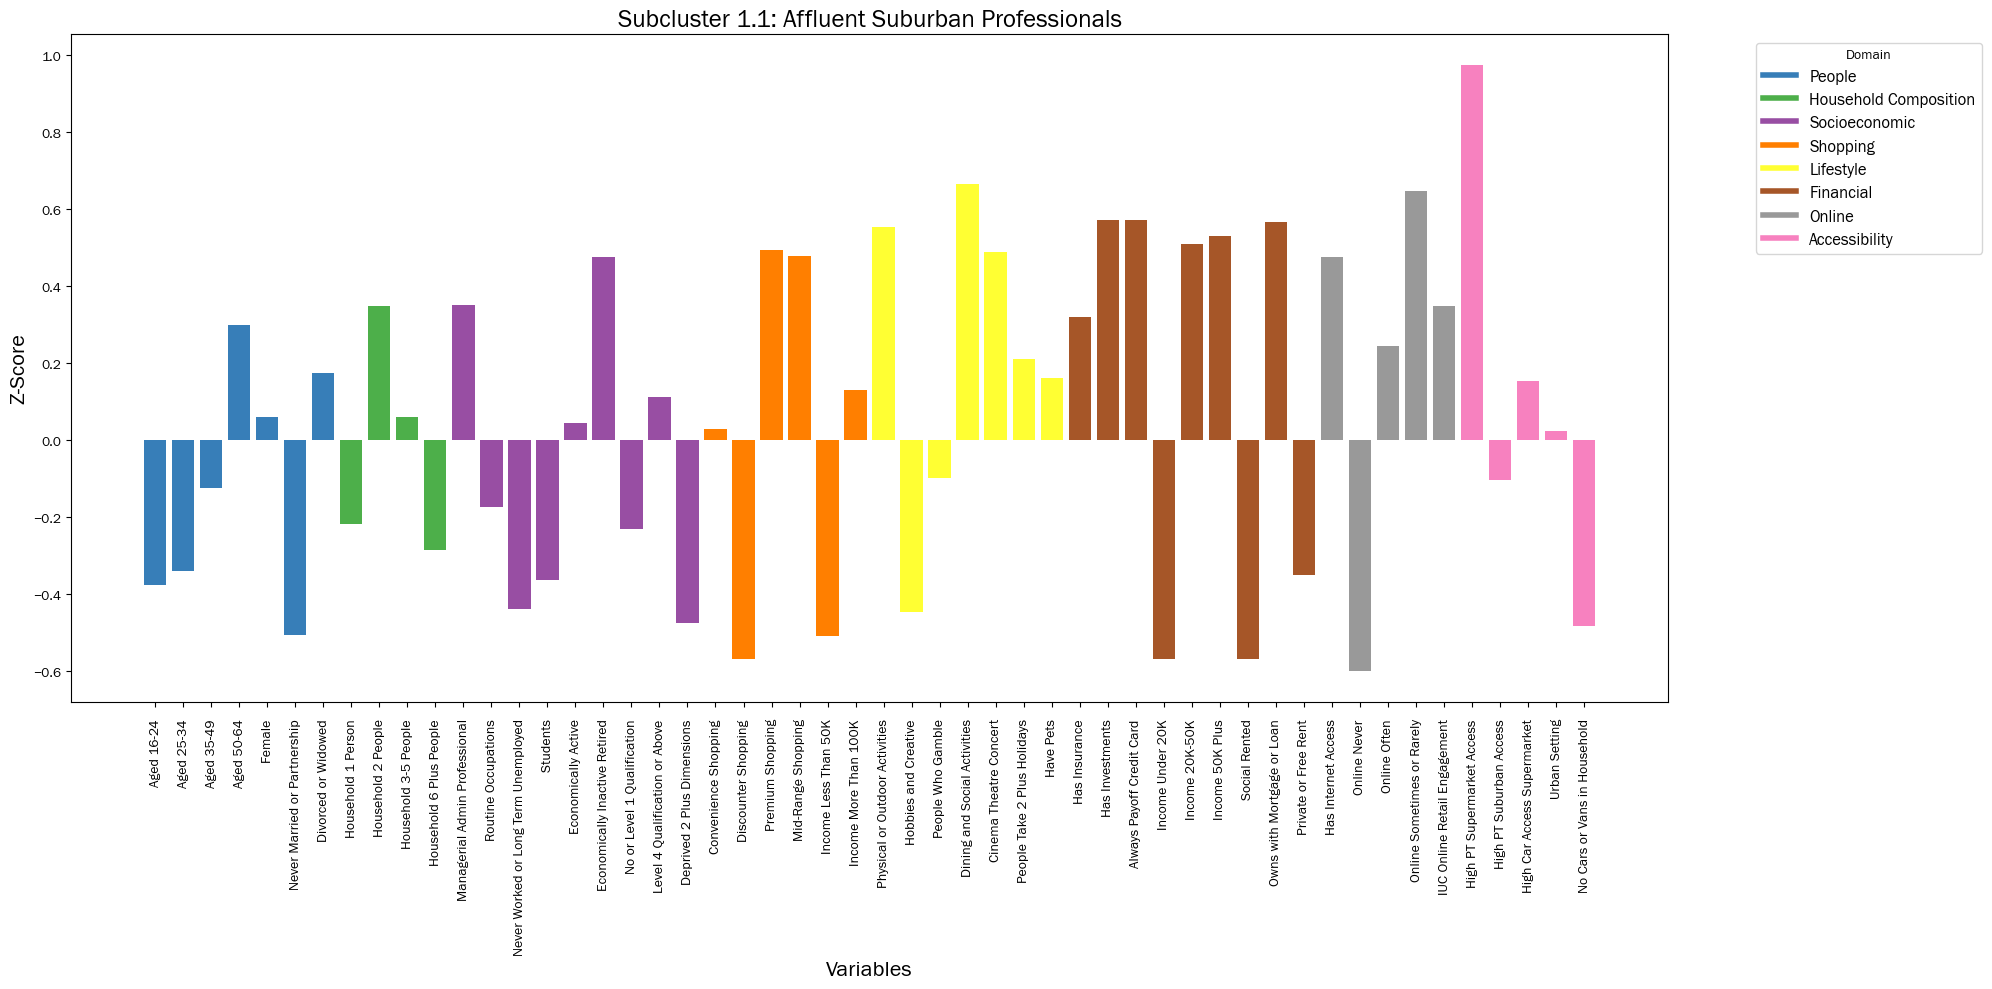

In [ ]:

# Update column references based on the actual DataFrame structure
z_scores = cluster_means_t.iloc[:, 1]  # Assuming Z-scores are in the second column
variables = cluster_means_t["Feature"]  # Variable names
domains = cluster_means_t["Domain"]  # Domain categories

# Define the color-blind friendly palette
domain_colors = {
    "People": "#377eb8",                # Blue
    "Household Composition": "#4daf4a", # Green
    "Socioeconomic": "#984ea3",        # Purple
    "Shopping": "#ff7f00",             # Orange
    "Lifestyle": "#ffff33",            # Yellow
    "Financial": "#a65628",            # Brown
    "Online": "#999999",               # Gray
    "Accessibility": "#f781bf",         # Pink
}


# Map colors to the Domain column
colors = domains.map(domain_colors)

# Create the bar plot
plt.figure(figsize=(20, 10))
bars = plt.bar(variables, z_scores, color=colors)

# Add labels and title
plt.title("Subcluster 1.1: Affluent Suburban Professionals", fontsize=18)
plt.xlabel("Variables", fontsize=16)
plt.ylabel("Z-Score", fontsize=16)
plt.xticks(rotation=90, fontsize=10, ha="center")

# Create a legend for the domains
handles = [plt.Line2D([0], [0], color=color, lw=4) for color in domain_colors.values()]
plt.legend(handles, domain_colors.keys(), title="Domain", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=12)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()


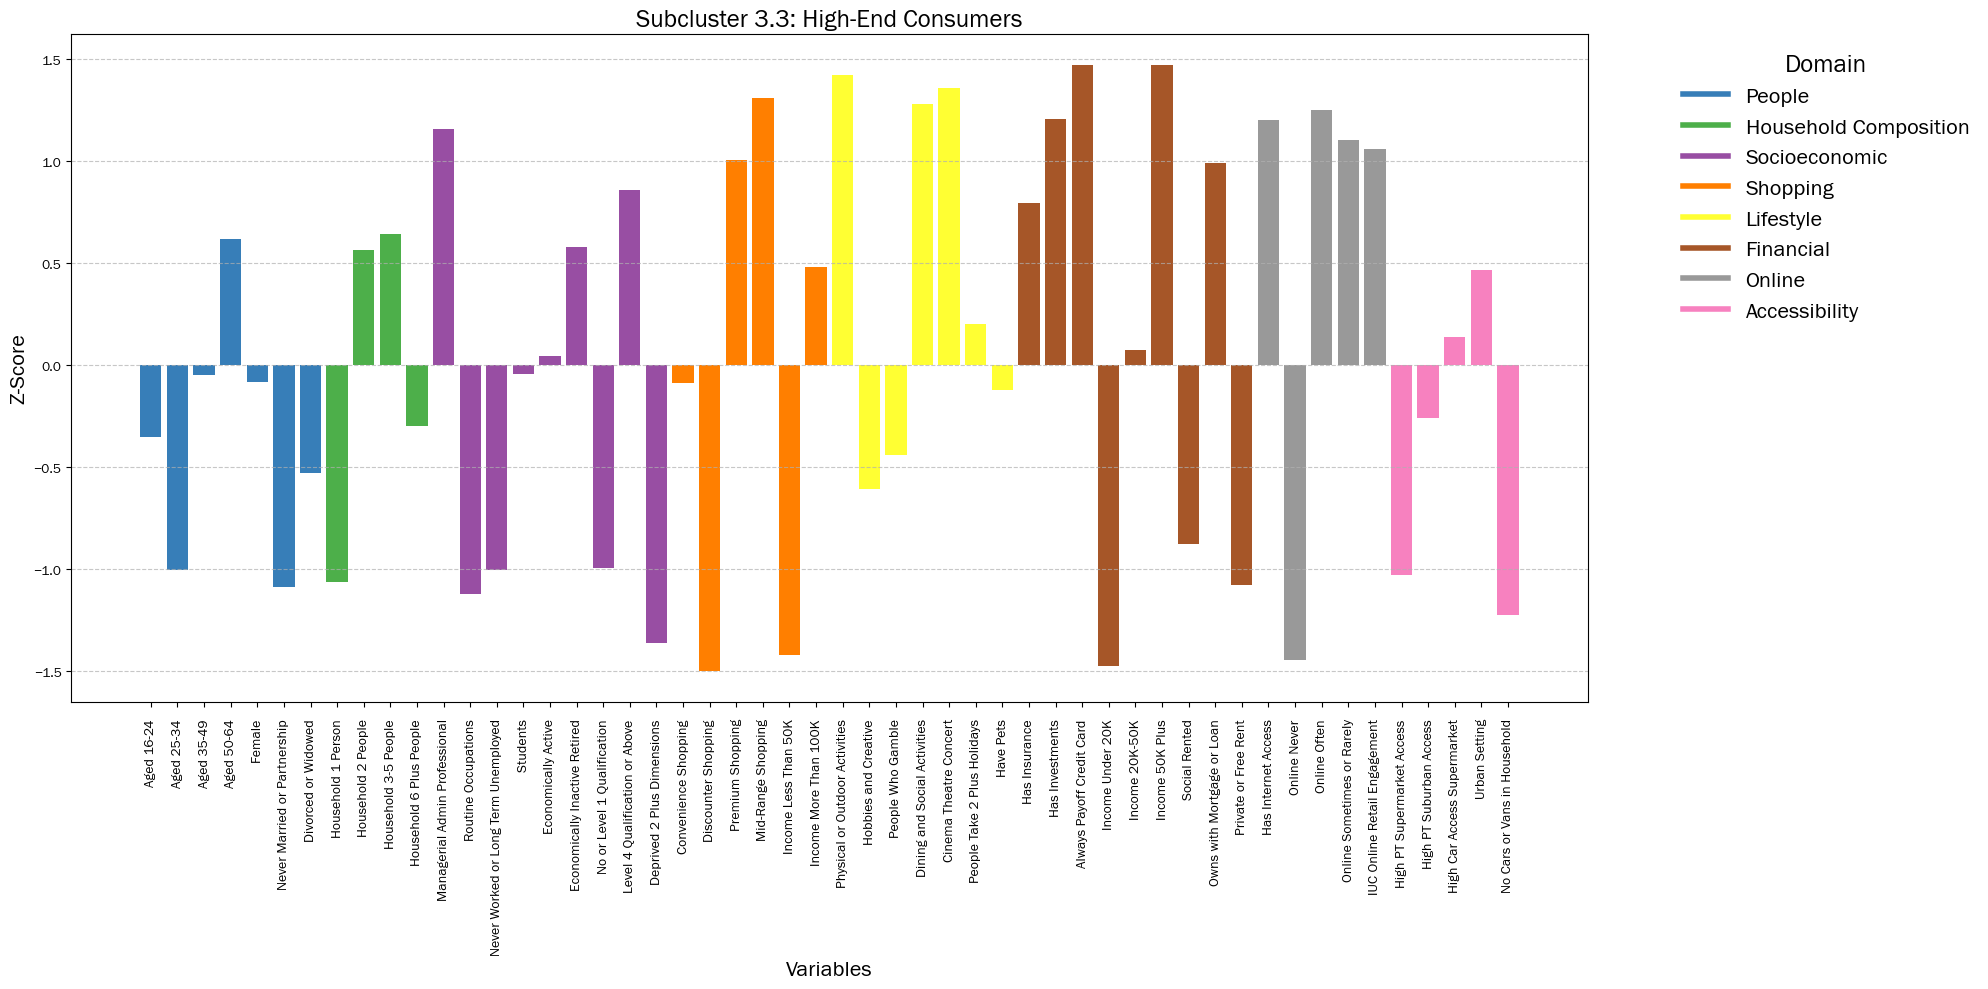

In [ ]:
### SUBCLUSTER GRAPHS FINAL SAME AS CLUSTER:

import matplotlib.pyplot as plt

# Set font to Franklin Gothic Book
plt.rcParams["font.family"] = "Franklin Gothic Book"

# Extract necessary data from DataFrame
z_scores = cluster_means_t.iloc[:, 9]  # Assuming Z-scores are in the second column
variables = cluster_means_t["Feature"]  # Variable names
domains = cluster_means_t["Domain"]  # Domain categories

# Define the color-blind friendly palette
domain_colors = {
    "People": "#377eb8",                # Blue
    "Household Composition": "#4daf4a", # Green
    "Socioeconomic": "#984ea3",        # Purple
    "Shopping": "#ff7f00",             # Orange
    "Lifestyle": "#ffff33",            # Yellow
    "Financial": "#a65628",            # Brown
    "Online": "#999999",               # Gray
    "Accessibility": "#f781bf",         # Pink
}

# Map colors to the Domain column
colors = domains.map(domain_colors)

# Create the bar plot
plt.figure(figsize=(20, 10))
bars = plt.bar(variables, z_scores, color=colors)

# Add gridlines to improve readability
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Dashed horizontal gridlines

# Add labels and title
plt.title("Subcluster 3.3: High-End Consumers", fontsize=18)
plt.xlabel("Variables", fontsize=16)
plt.ylabel("Z-Score", fontsize=16)
plt.xticks(rotation=90, fontsize=10, ha="center")

# Create a legend for the domains without a box
handles = [plt.Line2D([0], [0], color=color, lw=4) for color in domain_colors.values()]
legend = plt.legend(handles, domain_colors.keys(), title="Domain", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=16, frameon=False)

# Increase legend title font size
plt.setp(legend.get_title(), fontsize=18, weight='bold')

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()
